In [1]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 100.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f0e1704a2e5e9437356257e37b0d000a611ba677b434da6338d3dc12d13513ec
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import qiskit_ibm_runtime
print(qiskit_ibm_runtime.__version__)
import qiskit
print(qiskit.__version__)
import qiskit_aer
print(qiskit_aer.__version__)

0.45.0
2.3.0
0.17.2


In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer.noise import NoiseModel, pauli_error

In [4]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="LFsogztwnQVatNMK70c2hV_PMd7h_2-5vYl8zvCBI24p", overwrite=True)

Step1: Transformation (Repetition of qubits): Encode the information $|ψ⟩$ by using entanglement.
|Ψ⟩ = |1⟩
|Ψ⟩|00⟩ =>(entanglement) |111⟩

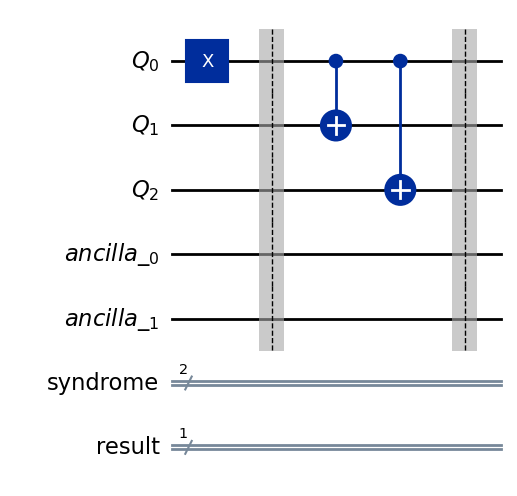

In [11]:
# 3 data qubits, 2 ancilla qubits, 2 syndrome bits

q_data = QuantumRegister(3, 'Q')
q_ancilla = QuantumRegister(2, 'ancilla_')
c_syn = ClassicalRegister(2, 'syndrome')
result_bit = ClassicalRegister(1, 'result')  # To measure the final state
qc = QuantumCircuit(q_data, q_ancilla, c_syn, result_bit)

# Encode: |ψ⟩|00> -> |111>
# We start with Q0 in |1> and spread it to Q1 and Q2
qc.x(q_data[0])
qc.barrier()
qc.cx(q_data[0], q_data[1])
qc.cx(q_data[0], q_data[2])
qc.barrier()
qc.draw(output="mpl")

Simulate an Error: Manually inject a bit-flip (X gate) on one of the data qubits to test the circuit.

In [6]:
# Simulate a bit-flip on qubit 0
qc.x(q_data[0])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "Q"), index=0>, <Qubit register=(3, "Q"), index=1>, <Qubit register=(3, "Q"), index=2>, <Qubit register=(2, "ancilla_"), index=0>, <Qubit register=(2, "ancilla_"), index=1>), clbits=())

or

In [7]:
# Construct a 1-qubit bit-flip error
p_error = 0.05
bit_flip = pauli_error([("X", p_error), ("I", 1 - p_error)])

# Apply the error to all identity gates
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(bit_flip, ['id'])

Step 2: Syndrome Extraction: Use the ancilla qubits to perform parity checks $(Z_{1}Z_{2})$ and $(Z_{2}Z_{3})$ without measuring the data qubits directly.

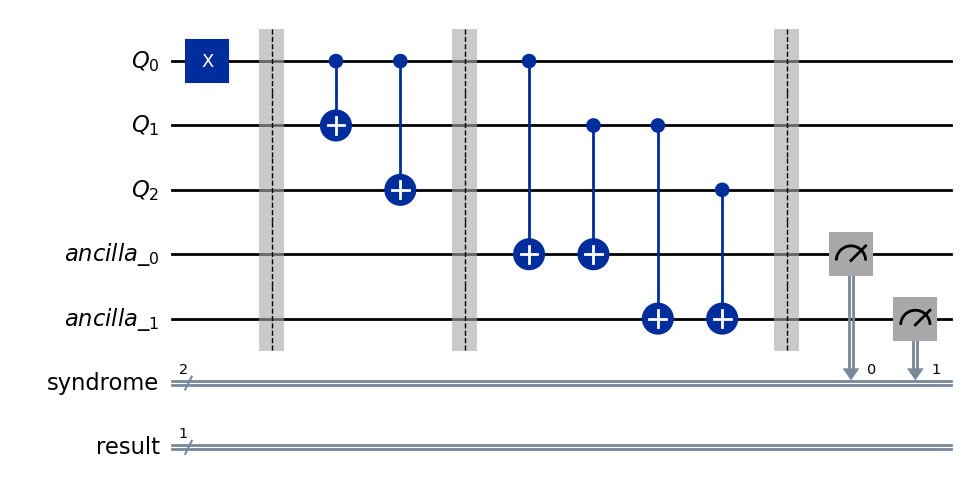

In [12]:
# Syndrome Extraction (Stabilizer Measurements)
# Check parity of x0 and x1
qc.cx(q_data[0], q_ancilla[0])
qc.cx(q_data[1], q_ancilla[0])

# Check parity of x1 and x2
qc.cx(q_data[1], q_ancilla[1])
qc.cx(q_data[2], q_ancilla[1])

qc.barrier()

# Measure the Syndrome (Measure ancillas to get the syndrome)
qc.measure(q_ancilla, c_syn)

qc.draw(output="mpl")

Step 3: Correction: Apply conditional logic using the if_test instruction to flip the corrupted qubit based on the measured syndrome.

In [9]:
# Note: syndrome is read as (ancilla_1)(ancilla_0)
# If syndrome is '01' (binary 1), qubit Q0 (1st bit) is flipped (based on parity logic)
with qc.if_test((c_syn, 1)):
    qc.x(q_data[0])

# Additional cases for syndromes '10'(binary 2) (qubit Q2-3rd bit) and '11' (binary 3) (qubit Q1-Second bit)
with qc.if_test((c_syn, 2)):
    qc.x(q_data[2])

with qc.if_test((c_syn, 3)):
    qc.x(q_data[1])

qc.barrier()

#Final Measurement (Verify the logical state is back to |1>)
# We measure Q0; if correction worked, it should be 1 with 100% probability
qc.measure(q_data[0], result_bit)

# Run Simulation
sim = AerSimulator()
job = sim.run(qc, shots=1000)
counts = job.result().get_counts()

print("Measurement Counts (Format: Result Syndrome):", counts)

Measurement Counts (Format: Result Syndrome): {'1 01': 1000}


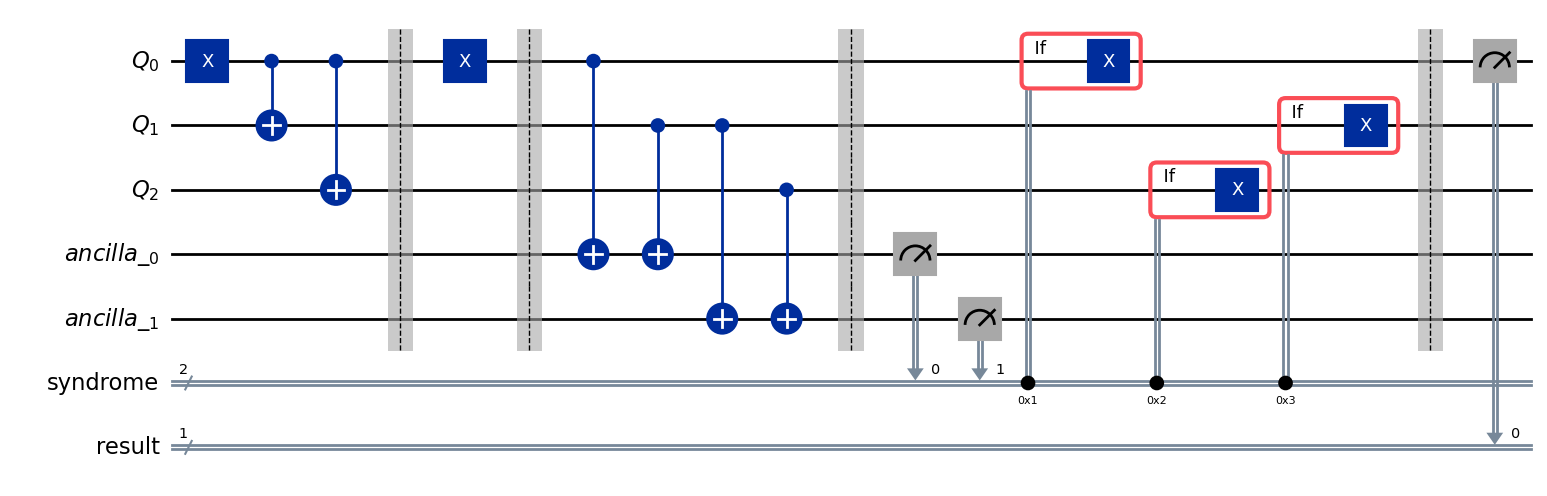

In [10]:
qc.draw(output="mpl")